# Earth Vital Signs: a first look

Three charts from the daily-updated **Earth Vital Signs** dataset: Arctic sea ice by year, the Mauna Loa CO2 curve, and ocean surface temperature against its 1991-2020 normal.

Every file is rebuilt each day from NOAA and NSIDC; the build code and checks are at https://github.com/yasumorishima/earth-vital-signs

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path("/kaggle/input/earth-vital-signs-daily"), Path("../data"), Path("data")]
DATA = next(p for p in candidates if (p / "sst_daily.csv").exists())

ice = pd.read_csv(DATA / "sea_ice_extent_daily.csv", parse_dates=["date"])
co2 = pd.read_csv(DATA / "co2_daily_mauna_loa.csv", parse_dates=["date"])
sst = pd.read_csv(DATA / "sst_daily.csv", parse_dates=["date"])
print({name: (len(df), str(df.date.max().date())) for name, df in
       [("sea ice", ice), ("co2", co2), ("sst", sst)]})

plt.rcParams.update({"axes.titlesize": 16, "axes.labelsize": 14, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "legend.fontsize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
GREY, RED, BLUE = "#c8c8c8", "#d62728", "#1f77b4"

{'sea ice': (31714, '2026-10-01'), 'co2': (15993, '2026-10-01'), 'sst': (16467, '2026-10-01')}


## 1. Arctic sea ice: every year since 1979 on one calendar

Grey lines are past years; the current year is red. The September minimum is where the decline shows most.

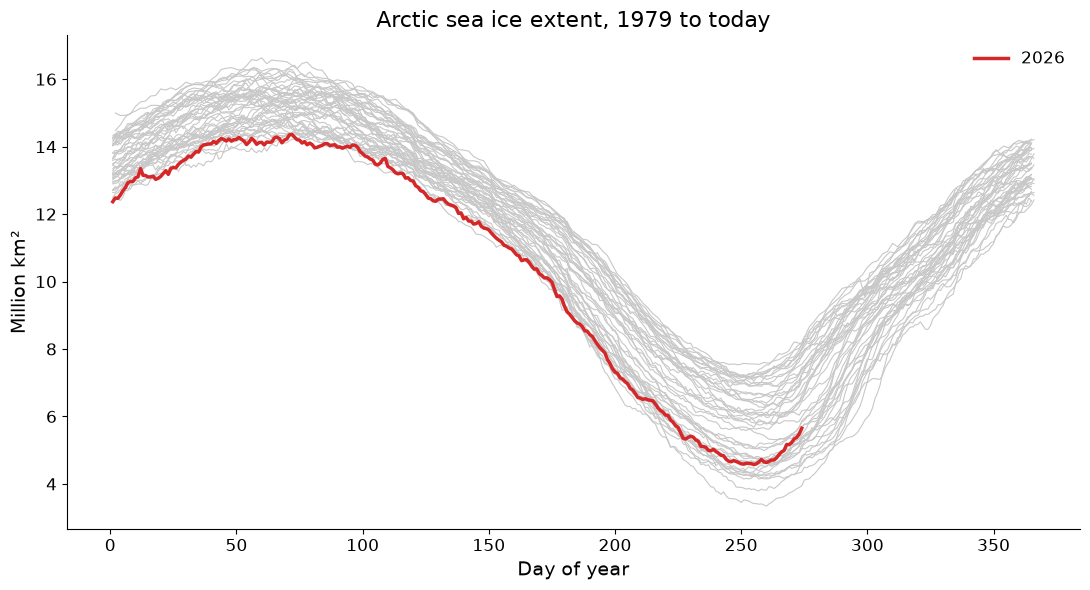

In [2]:
north = ice[(ice.hemisphere == "north") & (ice.date.dt.year >= 1979)].copy()
north["doy"] = north.date.dt.dayofyear
this_year = north.date.dt.year.max()

fig, ax = plt.subplots(figsize=(11, 6))
for y, g in north.groupby(north.date.dt.year):
    if y != this_year:
        ax.plot(g.doy, g.extent_mkm2, color=GREY, lw=0.8)
g = north[north.date.dt.year == this_year]
ax.plot(g.doy, g.extent_mkm2, color=RED, lw=2.5, label=str(this_year))
ax.set_title("Arctic sea ice extent, 1979 to today")
ax.set_xlabel("Day of year")
ax.set_ylabel("Million km²")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [3]:
# Annual minimum: how much smaller has the September low become?
mins = north[north.date.dt.year < this_year].groupby(north.date.dt.year).extent_mkm2.min()
print(mins.head(3).round(2).to_dict(), "...", mins.tail(3).round(2).to_dict())

{1979: 6.9, 1980: 7.53, 1981: 6.9} ... {2023: 4.24, 2024: 4.24, 2025: 4.54}


## 2. CO2 at Mauna Loa

The yearly saw-tooth is the Northern Hemisphere's vegetation breathing; the climb under it is the long-term rise.

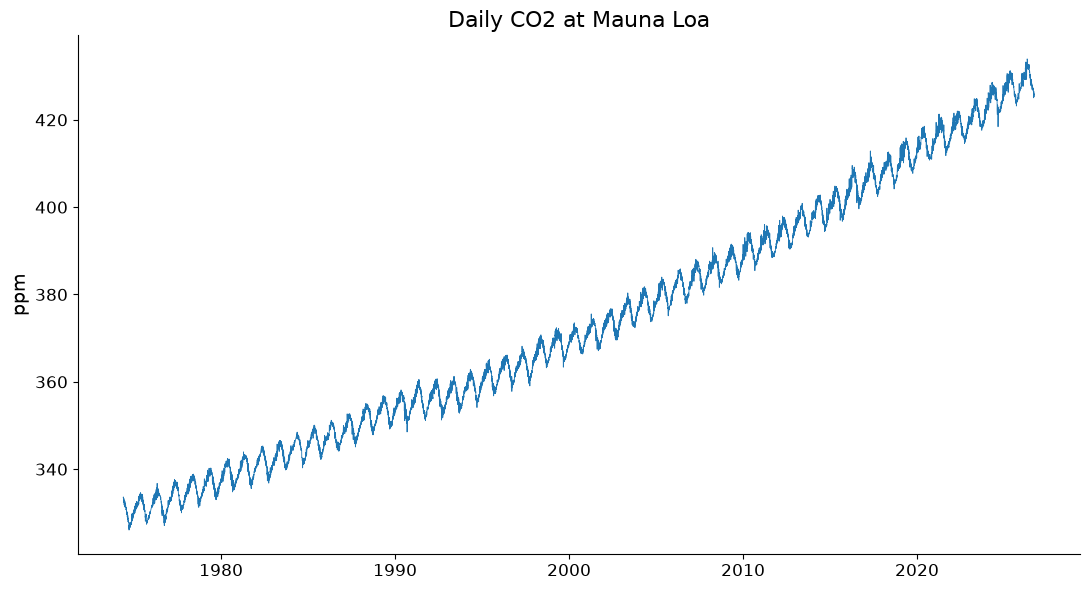

Average yearly increase, last 10 full years: 2.65 ppm


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(co2.date, co2.co2_ppm, color=BLUE, lw=0.6)
ax.set_title("Daily CO2 at Mauna Loa")
ax.set_ylabel("ppm")
plt.tight_layout()
plt.show()

yearly = co2.groupby(co2.date.dt.year).co2_ppm.mean()
full_years = yearly.loc[1975:co2.date.dt.year.max() - 1]
print("Average yearly increase, last 10 full years:", round(full_years.diff().tail(10).mean(), 2), "ppm")

## 3. Ocean surface temperature against its normal

Daily mean SST between 60S and 60N, minus the 1991-2020 average for the same calendar day. Values above zero are warmer than normal.

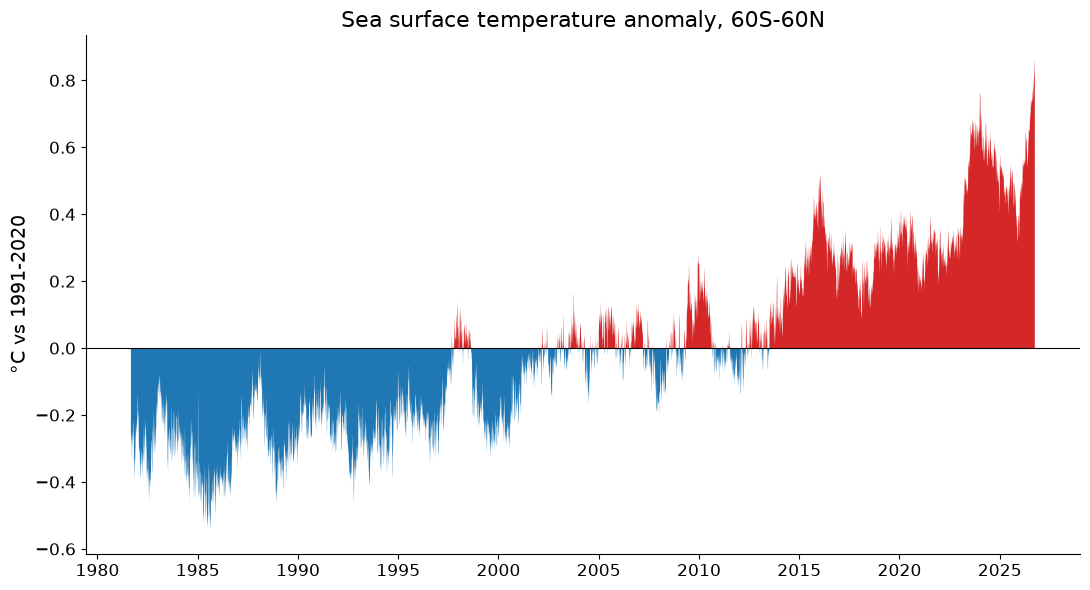

Warmest 5 days on record:
      date  world_60s_60n
2026-09-19        21.1834
2026-08-26        21.1832
2026-08-25        21.1806
2026-08-27        21.1796
2026-09-07        21.1792


In [5]:
s = sst.set_index("date")["world_60s_60n_anom_1991_2020"]
fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(s.index, s.values, 0, where=s.values >= 0, color=RED, lw=0)
ax.fill_between(s.index, s.values, 0, where=s.values < 0, color=BLUE, lw=0)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Sea surface temperature anomaly, 60S-60N")
ax.set_ylabel("°C vs 1991-2020")
plt.tight_layout()
plt.show()

print("Warmest 5 days on record:")
print(sst.nlargest(5, "world_60s_60n")[["date", "world_60s_60n"]].to_string(index=False))

## Ideas to try

- Forecast the September Arctic minimum from the extent in June and July.
- Compare the Antarctic record (`hemisphere == "south"`) with the Arctic: the trends differ.
- Relate the North Atlantic SST anomaly (`north_atlantic_0_60n_0_80w_anom_1991_2020`) to hurricane seasons.
- Use `greenhouse_gases_monthly.csv` to compare growth rates of CO2, methane and nitrous oxide.

Please cite the original producers (NSIDC, NOAA GML with Scripps, NOAA OISST/PSL) as listed in the dataset description.